# Dependency package

In [12]:
import os
import time
import numpy as np

import mne
from mne.channels import make_standard_montage
# from mne.decoding import CSP

import sklearn
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.ensemble import VotingClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

import scipy
from scipy import stats
from scipy.io import loadmat
from scipy.signal import welch

from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

import pyriemann
from pyriemann.clustering import Kmeans as pyKmeans

print(f"numpy version: {np.__version__}")
print(f"mne version: {mne.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"pyriemann version: {pyriemann.__version__}")
start_time = time.time()

numpy version: 2.2.6
mne version: 1.10.1
sklearn version: 1.7.2
scipy version: 1.15.3
pyriemann version: 0.10


# Dataset Setting

In [ ]:
# Select dataset
# 0: BCICIV_2a
# 1: BCICIV_2b
# 2: BCICIV_1
Dataset_Selection = 2


match Dataset_Selection:
    case 0:
        gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
        mat_dirPath = None
        participants = [] # EEG-MI 受試者
        participantsNum = 9 # EEG-MI 受試者人數
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'A0{i}T']  # bci4_2A
        saveResultPath = './result_bci4_2a/' # 結果儲存資料夾
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2A 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG-Fz' : 'Fz'  ,
            'EEG-0'  : 'FC3' ,
            'EEG-1'  : 'FC1' ,
            'EEG-2'  : 'FCz' ,
            'EEG-3'  : 'FC2' ,
            'EEG-4'  : 'FC4' ,
            'EEG-5'  : 'C5'  ,
            'EEG-C3' : 'C3'  ,
            'EEG-6'  : 'C1'  ,
            'EEG-Cz' : 'Cz'  ,
            'EEG-7'  : 'C2'  ,
            'EEG-C4' : 'C4'  ,
            'EEG-8'  : 'C6'  ,
            'EEG-9'  : 'CP3' ,
            'EEG-10' : 'CP1' ,
            'EEG-11' : 'CPz' ,
            'EEG-12' : 'CP2' ,
            'EEG-13' : 'CP4' ,
            'EEG-14' : 'P1'  ,
            'EEG-Pz' : 'Pz'  ,
            'EEG-15' : 'P2'  ,
            'EEG-16' : 'POz' ,
            'EOG-left'   : 'EOG-left',
            'EOG-central': 'EOG-central',
            'EOG-right'  : 'EOG-right'
        }
        channel_types = {
            'EEG-Fz' : 'eeg',
            'EEG-0'  : 'eeg',
            'EEG-1'  : 'eeg',
            'EEG-2'  : 'eeg',
            'EEG-3'  : 'eeg',
            'EEG-4'  : 'eeg',
            'EEG-5'  : 'eeg',
            'EEG-C3' : 'eeg',
            'EEG-6'  : 'eeg',
            'EEG-Cz' : 'eeg',
            'EEG-7'  : 'eeg',
            'EEG-C4' : 'eeg',
            'EEG-8'  : 'eeg',
            'EEG-9'  : 'eeg',
            'EEG-10' : 'eeg',
            'EEG-11' : 'eeg',
            'EEG-12' : 'eeg',
            'EEG-13' : 'eeg',
            'EEG-14' : 'eeg',
            'EEG-Pz' : 'eeg',
            'EEG-15' : 'eeg',
            'EEG-16' : 'eeg',
            'EOG-left'   : 'eog',
            'EOG-central': 'eog',
            'EOG-right'  : 'eog'
        }
        downsamplingFreq = None
    case 1:
        gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'
        mat_dirPath = None
        participants = []
        participantsNum = 9
        participantsId = ['B0103T','B0203T','B0303T','B0403T','B0503T','B0603T','B0703T','B0803T','B0303T']
        filenamePrefix = ''
        filenamePostfix = '.gdf'
        for i in participantsId:
            participants = participants + [i]  # bci4_2B
        saveResultPath = './result_bci4_2b/'
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG:C3' : 'C3'  ,
            'EEG:Cz' : 'Cz'  ,
            'EEG:C4' : 'C4'  ,
            'EOG:ch01':'EOG:ch01',
            'EOG:ch02':'EOG:ch02',
            'EOG:ch03':'EOG:ch03'
        }
        channel_types = {
            'EEG:C3'   : 'eeg',
            'EEG:Cz'   : 'eeg',
            'EEG:C4'   : 'eeg',
            'EOG:ch01' : 'eog',
            'EOG:ch02' : 'eog',
            'EOG:ch03' : 'eog'
        }
        downsamplingFreq = None
    case 2:
        gdf_dirPath = None
        mat_dirPath = f'../../dataset/BCICIV_1calib_1000Hz_mat/'
        participants = []
        participantsNum = 3
        participantsId = ['ds1b','ds1c','ds1g']
        filenamePrefix = 'BCICIV_calib_'
        filenamePostfix = '_1000Hz.mat'
        for i in participantsId:
            participants = participants + [i]  # bci4_1
        saveResultPath = './result_bci4_1/'
        target_keys = ['Left', 'Right'] # 任務
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = None
        channel_types = None
        downsamplingFreq = 250

try:
    os.mkdir(saveResultPath) # 創建結果儲存資料夾
    os.mkdir(saveResultPath +'./confuseMatrix/') # 創建結果儲存資料夾
except:
    print("file exist")
    pass

file exist


# Pre-Processing Setting

In [14]:
# band pass filter
fs = 250
lowcut = 8
highcut = 30
filter_order = 8
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 擷取實驗時間，0秒是cued開始
# C: number of channels
# P: number of temporal points
# N: number of trials
# (tmax-tmin)*250+1=500
# tmax = (P-1)/fs+tmin
time_interval = 3.5
P = time_interval*fs
tmin = 0.5
tmax = (P-1)/fs+tmin
print(f"Time from {tmin} s to {tmax} s, sample point: {P}")

# CSP M值
M = 3

Time from 0.5 s to 3.996 s, sample point: 875.0


# Data Segmentation

In [15]:
montage = make_standard_montage('standard_1020')
if channel_rename_map:
    eeg_only_channels = [
        name
        for name in channel_rename_map.values()
        if not name.startswith('EOG')
    ]

## Create Epoch training data and testing data
epochs = {}
for subject in participants:
    if gdf_dirPath:
        gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
        try:
            raw = mne.io.read_raw_gdf(gdf_filepath, preload=True, verbose="ERROR")
        except Exception as e:
            print(f"讀取 GDF 檔案時發生錯誤: {e}")
            raise
    elif mat_dirPath:
        try:
            mat_filepath = mat_dirPath + f'./{filenamePrefix}{subject}{filenamePostfix}'
            mat_data = loadmat(mat_filepath, struct_as_record=False, squeeze_me=True)
            eeg_data = mat_data['cnt']     # 這是訊號矩陣 (Time x Channels)
            sfreq = mat_data['nfo'].fs     # 採樣率
            ch_names = mat_data['nfo'].clab # 通道名稱
            classes = mat_data['nfo'].classes
            events_sample = mat_data['mrk'].pos - 1
            events_id = np.where(mat_data['mrk'].y == -1, 1, 2)

            info = mne.create_info(ch_names=list(ch_names), sfreq=sfreq, ch_types='eeg', verbose='Error')
            raw = mne.io.RawArray(eeg_data.T * 1e-6, info, verbose='Error')

            events = np.column_stack((
                events_sample,
                np.zeros_like(events_sample, dtype=int),
                events_id.astype(int)
            ))
            mapping = {1: 'Left', 2: 'Right'}
            annot = mne.annotations_from_events(
                events=events,
                sfreq=raw.info['sfreq'],
                event_desc=mapping
            )
            raw.set_annotations(annot)
        except Exception as e:
            print(f"讀取 GDF 檔案時發生錯誤: {e}")
            raise

    ## Raw setting
    if channel_types:
        raw.set_channel_types(channel_types, verbose="ERROR") # 設定電擊種類是EEG還是EOG
    if channel_rename_map:
        raw.rename_channels(channel_rename_map, verbose="ERROR") # 重新命名電擊名稱符合10-20系統
    if downsamplingFreq:
        raw.resample(sfreq=downsamplingFreq) # downsampling
    raw.set_eeg_reference([], verbose="ERROR") # 設定reference電擊
    raw.set_montage(montage, on_missing='ignore', verbose="ERROR") # 設定10-20系統

    ## Regression
    # model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    # model.fit(raw)
    # raw = model.apply(raw)
    if channel_rename_map:
        raw.pick_channels(eeg_only_channels, verbose="ERROR") # Remove EOG data
    raw.filter( # Bandpass filter
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',
        iir_params=iir_params,
        verbose="ERROR"
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    new_id_mapping = {old_id: i for i, old_id in enumerate(kept_event_ids.values())}
    kept_event_ids = {key: i for i, key in enumerate(kept_event_ids.keys())}
    for i in range(len(events_of_interest)):
        old_val = events_of_interest[i, 2]
        events_of_interest[i, 2] = new_id_mapping[old_val]

    baseline = None # 不做基線校正，或您可以定義 (-0.5, 0)
    epoch = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False,           # 暫時不應用投影
        verbose="ERROR"
    )
    epochs[subject] = epoch
    print(f"{subject} epoch create successful")

A01T epoch create successful
A02T epoch create successful
A03T epoch create successful
A04T epoch create successful
A05T epoch create successful
A06T epoch create successful
A07T epoch create successful
A08T epoch create successful
A09T epoch create successful


# Bypass

In [16]:
class Bypass(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        '''
        X: 原始EEG訊號(trials, channels, samples)
        feat_log: output, (trials, p)
        p: the number of feature selected
        '''
        feat_var = np.var(X, axis=2)
        feat_log = np.log(feat_var + 1e-10)
        return feat_log

# Feature Transfer (CSP)

In [17]:
class CSP(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=4, reg=1e-10):
        self.n_components = n_components
        self.reg = reg # 我們推導中的 gamma
        self.filters_ = None

    def __trace_normalization(self, X):
        '''
        Calculate the covariance for each trial and normalization trace
        ---------
        X: input data, (trials, chs, samples)
        trace_norm_cov: return data, (trials, chs, chs)
        '''
        X_T = np.transpose(X, (0,2,1))
        cov = X @ X_T
        trace = np.trace(cov, axis1=1, axis2=2).reshape(cov.shape[0], 1, 1)
        trace_norm_cov = cov/trace
        return trace_norm_cov

    def __covarianc_mean(self, X):
        '''
        Calculate the covariance for each trial and return their average
        ---------
        X: input data, covariance matrix, (trials, chs, chs)
        cov_mean: return data, mean of the covariance, (chs, chs)
        '''
        cov_mean = np.mean(X, axis=0)
        return cov_mean

    def fit(self, X, y):
        '''
        X: input data, (trials, chs, samples)
        y: input label, (trials)
        ---------
        訓練csp轉移矩陣儲存到self.filter
        '''
        ntrials, nchannels, nsamples = X.shape
        # 1. 準備數據：拆分兩類
        class1 = X[y == 0]
        class2 = X[y == 1]
        class1 = self.__trace_normalization(class1)
        class2 = self.__trace_normalization(class2)

        # 2. 計算各自的平均協方差矩陣
        # (epochs, channels, times) -> (channels, channels)
        cov_1 = self.__covarianc_mean(class1)
        cov_2 = self.__covarianc_mean(class2)

        sigma_total = cov_1 + cov_2
        eigenvalues, U = np.linalg.eigh(sigma_total)
        P = U @ np.diag((np.maximum(eigenvalues, 0) + self.reg) ** -0.5) @ U.T
        transformed_cov = P.T @ cov_1 @ P
        evals, B = np.linalg.eigh(transformed_cov)
        ix = np.argsort(evals)[::-1]

        # 3. 選擇n個csp
        if 2*self.n_components < nchannels:
            half = self.n_components // 2
            head_idx = ix[:self.n_components-half]
            tail_idx = ix[-half:]
            ix_selected = np.concatenate([head_idx, tail_idx])
            W = (P @ B)[:, ix_selected]
        else:
            W = (P @ B)
        W = W.T
        self.filters_ = W
        return self

    def transform(self, epochs_data):
        '''
        應用空間濾波器: Z = W * X
        feat_log: output, (trials, p)
        p: the number of feature selected
        '''
        feat = []
        for e in epochs_data:
            feat.append(np.dot(self.filters_, e))
        feat = np.array(feat)
        feat_var = np.var(feat, axis=2)
        feat_log = np.log(feat_var + 1e-10)
        return feat_log

# Tangent Space Mapping (TSM)

In [18]:
class TSM(BaseEstimator, TransformerMixin):
    def __init__(self, reg=1e-10):
        self.centroid = None
        self.reg = reg

    def __raw2covariance(self, X):
        '''
        ---------------
        將X轉成cov回傳.
        ---------------
        X shape: (trials, channels, samples)
        ---------------
        cov shape: (trials, channels, channels)
        ---------------
        '''
        n_trials, n_channels, n_samples = X.shape
        X_T = np.transpose(X, (0,2,1))
        cov = X @ X_T / (n_samples - 1)
        return cov

    def __find_centroid(self, X):
        """ 計算黎曼中心 """
        model_py = pyKmeans(n_clusters=1, metric='riemann').fit(X)
        return model_py.centroids()[0]

    def __matrix_log(self, M):
        """計算矩陣對數 (僅使用 numpy 特徵分解)"""
        evals, evecs = np.linalg.eigh(M)
        return evecs @ np.diag(np.log(evals)) @ evecs.T

    def __matrix_sqrt(self, M):
        """計算矩陣平方根"""
        evals, evecs = np.linalg.eigh(M)
        return evecs @ np.diag(np.sqrt(evals)) @ evecs.T

    def __matrix_inv_sqrt(self, M):
        """計算矩陣負平方根"""
        evals, evecs = np.linalg.eigh(M)
        return evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

    def __upper(self, K):
        """模擬 upper() 操作：提取上三角並向量化"""
        n = K.shape[0]
        # 提取上三角索引
        idx = np.triu_indices(n)
        vec = K[idx].copy()

        # 為了保持範數一致，非對角線元素乘以 sqrt(2)
        # (這在很多 paper 的 upper 實作中是標準做法)
        diag_mask = np.eye(n, dtype=bool)[idx]
        vec[~diag_mask] *= np.sqrt(2)
        return vec

    def fit(self, X, y=None):
        cov = self.__raw2covariance(X)
        self.centroid = self.__find_centroid(cov)
        return self

    def transform(self, X):
        '''
        ---------------
        找到trials中心的covariance matrix當作參考點, 將其他的matrix mapping到參考點的tangent space.
        ---------------
        X shape: (trials, channels, samples)
        ---------------
        '''
        cov = self.__raw2covariance(X)
        P_half = self.__matrix_sqrt(self.centroid)
        P_inv_half = self.__matrix_inv_sqrt(self.centroid)
        Ks = []
        for Q in cov:
            # 套用公式: K = P^0.5 * log(P^-0.5 * Q * P^-0.5) * P^0.5
            inner = P_inv_half @ Q @ P_inv_half
            K = P_half @ self.__matrix_log(inner) @ P_half
            K_upper = self.__upper(K)
            Ks.append(K_upper)
        Ks = np.array(Ks)
        return Ks

# Data Splitting

In [19]:
trainData = {}
testData = {}
seed = 42
for subject in participants:
    X = epochs[subject].get_data() # trials,chs,samples
    X = X - np.mean(X, axis=-1, keepdims=True)
    y = epochs[subject].events[:, 2]

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

    trainData[subject] = {
        'Data': X_train,
        'Label': y_train
    }

    testData[subject] = {
        'Data': X_test,
        'Label': y_test
    }


# Ablation

In [20]:
def get_ablation_pipeline(M=3, use_csp=True, use_tsm=True):
    # 1. 建立動態特徵清單
    features_list = []

    if use_csp:
        features_list.append(('csp', CSP(n_components=2*M)))
    if use_tsm:
        features_list.append(('tsm', TSM()))
    if not(use_csp) and not(use_tsm):
        features_list = []
        features_list.append(('bypass', Bypass()))

    # 2. 封裝成 FeatureUnion
    combined_features = FeatureUnion(features_list)

    # 3. 回傳完整的 Pipeline
    return Pipeline([
        ('features', combined_features),
        ('scaler', StandardScaler()),
        ('clf', LDA()),
    ])

def ablation_config():
    variants = ["Full", "TSM", "CSP", "ByPass"]
    ablate_configs = {
        "ByPass":   {"use_csp": False, "use_tsm": False},
        "Full":     {"use_csp": True , "use_tsm": True },
        "TSM":      {"use_csp": False, "use_tsm": True },
        "CSP":      {"use_csp": True , "use_tsm": False},
    }
    return variants, ablate_configs

def ablation(func):
    def wrap(*args, **kwargs):
        results = {}
        variants, ablate_configs = ablation_config()
        for var in variants:
            pipe = get_ablation_pipeline(M=3, use_csp=ablate_configs[var]["use_csp"], use_tsm=ablate_configs[var]["use_tsm"])
            result = func(pipe = pipe, *args, **kwargs)
            results[var] = result
        return results
    return wrap

# Train & Testing

In [21]:
@ablation
def train(pipe = None):
    result = {}
    for subject in participants:
        if not pipe:
            combined_features = FeatureUnion([
                ('csp_part', CSP(n_components=2*M)),
            ])
            pipe = Pipeline([
                ('features', combined_features),
                ('scaler', StandardScaler()), # 不同的特徵量級不同，一定要 Scaler
                ('clf', LDA()),
            ])

        # 評估模型穩定度
        X = epochs[subject].get_data()
        y = epochs[subject].events[:, 2]
        cv_scores = cross_val_score(pipe, trainData[subject]['Data'], trainData[subject]['Label'], cv=5)

        # 評估泛化能力
        pipe.fit(trainData[subject]['Data'], trainData[subject]['Label'])
        test_scores = pipe.score(testData[subject]['Data'], testData[subject]['Label'])
        y_pred = pipe.predict(testData[subject]['Data'])
        y_probs = pipe.predict_proba(testData[subject]['Data'])[:, 1]
        conf_matrix = confusion_matrix(testData[subject]['Label'], y_pred)

        result[subject] = {
            'cv_scores': cv_scores,
            'test_conf': conf_matrix,
            'y_true': testData[subject]['Label'],
            'y_probs': y_probs,
        }

    return result

In [22]:
results = train()

# Report Analysis

In [23]:
def analysis(result, output_filename = None):
    test_acc_all = {}
    test_precision_all = {}
    test_recall_all = {}
    test_specificity_all = {}
    test_f1_all = {}
    test_kappa_all = {}
    for subject in participants:
        test_acc_all[subject] = []
        test_precision_all[subject] = []
        test_recall_all[subject] = []
        test_specificity_all[subject] = []
        test_f1_all[subject] = []
        test_kappa_all[subject] = []

    # 計算每個人的統計指標
    for subject in participants:
        TN = result[subject]['test_conf'][0][0]
        FP = result[subject]['test_conf'][0][1]
        FN = result[subject]['test_conf'][1][0]
        TP = result[subject]['test_conf'][1][1]
        test_trials = result[subject]['test_conf'].sum()

        test_acc  = (TN+TP)/test_trials
        test_precision = TP/(TP+FP)
        test_recall = TP/(TP+FN)
        test_specificity = TN/(FP+TN)
        test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
        test_pe = ((TP+FN)/test_trials)*((TP+FP)/test_trials)+((TN+FP)/test_trials)*((FN+TN)/test_trials)
        test_kappa = (test_acc-test_pe)/(1-test_pe)

        test_acc_all[subject]       = round(test_acc*100,1)
        test_precision_all[subject] = round(test_precision*100,1)
        test_recall_all[subject]    = round(test_recall*100,1)
        test_specificity_all[subject] = round(test_specificity*100,1)
        test_f1_all[subject]        = round(test_f1,2)
        test_kappa_all[subject]     = round(test_kappa,2)


    test_acc_all['avg']         = round(np.mean(list(test_acc_all.values())), 1)
    test_precision_all['avg']   = round(np.mean(list(test_precision_all.values())), 1)
    test_recall_all['avg']      = round(np.mean(list(test_recall_all.values())), 1)
    test_specificity_all['avg'] = round(np.mean(list(test_specificity_all.values())), 1)
    test_f1_all['avg']          = round(np.mean(list(test_f1_all.values())), 2)
    test_kappa_all['avg']       = round(np.mean(list(test_kappa_all.values())), 2)

    test_acc_all['std']         = round(np.std(list(test_acc_all.values())), 1)
    test_precision_all['std']   = round(np.std(list(test_precision_all.values())), 1)
    test_recall_all['std']      = round(np.std(list(test_recall_all.values())), 1)
    test_specificity_all['std'] = round(np.std(list(test_specificity_all.values())), 1)
    test_f1_all['std']          = round(np.std(list(test_f1_all.values())), 2)
    test_kappa_all['std']       = round(np.std(list(test_kappa_all.values())), 2)

    # 創建表格
    data = {
        'Subject'  : [subject for subject in participants] + ['Avg.'] + ['Std.'],
        'Accuracy' : [f"{test_acc_all[subject]:.1f}" for subject in participants] + [test_acc_all['avg']] + [test_acc_all['std']],
        'Precision': [f"{test_precision_all[subject]:.1f}" for subject in participants] + [test_precision_all['avg']] + [test_precision_all['std']],
        'Recall'   : [f"{test_recall_all[subject]:.1f}" for subject in participants] + [test_recall_all['avg']] + [test_recall_all['std']],
        'Specificity': [f"{test_specificity_all[subject]:.1f}" for subject in participants] + [test_specificity_all['avg']] + [test_specificity_all['std']],
        'F1-score' : [f"{test_f1_all[subject]:.2f}" for subject in participants] + [f"{test_f1_all['avg']:.2f}"] + [test_f1_all['std']],
        'Kappa'    : [f"{test_kappa_all[subject]:.2f}" for subject in participants] + [f"{test_kappa_all['avg']:.2f}"] + [test_kappa_all['std']]
    }

    df = pd.DataFrame(data)

    # print("--- testing for generalization ---")
    # print(df)
    if not output_filename:
        output_filename = saveResultPath + './stat_results_testing.csv'

    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )

    print(f"數據已成功匯出到 '{output_filename}'。")
    return df

def robust_analysis(results):
    variants, ablate_configs = ablation_config()
    analysis_results = {}
    cv_scores = {}
    for var in variants:
        cv_scores[var] = []
        for subject in participants:
            cv_scores[var].append(results[var][subject]['cv_scores']*100)
        cv_scores[var] = np.array(cv_scores[var])

    # 創建表格
    data = {'Subject'  : participants + ['Avg.'] + ['Std.'],}
    for i in range(len(variants)):
        data[variants[i]] = np.round(np.concatenate((cv_scores[variants[i]].mean(axis=1), [cv_scores[variants[i]].mean(), cv_scores[variants[i]].std()])), decimals=1)

    df = pd.DataFrame(data)
    print("--- cv score for robustness ---")
    print(df)
    output_filename = saveResultPath + './stat_results_cv.csv'
    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )
    print(f"\n數據已成功匯出到 '{output_filename}'。")
    return df

## Robust

In [24]:
robust_result = robust_analysis(results)
print()

--- cv score for robustness ---
   Subject  Full   TSM   CSP  ByPass
0     A01T  74.8  80.0  83.5    73.9
1     A02T  53.0  47.0  60.0    57.4
2     A03T  84.3  86.1  97.4    87.8
3     A04T  70.4  70.4  68.7    65.2
4     A05T  53.0  58.3  57.4    49.6
5     A06T  58.3  58.3  71.3    62.6
6     A07T  68.7  64.3  73.0    70.4
7     A08T  86.1  84.3  99.1    93.9
8     A09T  61.7  59.1  73.9    74.8
9     Avg.  67.8  67.5  76.0    70.6
10    Std.  14.4  14.9  16.4    16.1

數據已成功匯出到 './result_bci4_2a/./stat_results_cv.csv'。



## Generalization

In [25]:
def generalization_analysis(results):
    variants, ablate_configs = ablation_config()
    analysis_results = {}
    for var in variants:
        output_filename = saveResultPath + f"./stat_results_{var}_testing.csv"
        analysis_results[var] = analysis(results[var], output_filename=output_filename)
    return analysis_results

def test_compare(results):
    variants, ablate_configs = ablation_config()
    analysis_results = generalization_analysis(results)
    accuracy = []
    xlabel = []
    for var in variants:
        accuracy.append(analysis_results[var]['Accuracy'])
        xlabel.append(var)
    data = {'Subject'  : participants + ['Avg', 'Std']}
    for i in range(len(variants)):
        data[variants[i]] = accuracy[i]

    df = pd.DataFrame(data)

    print("--- Generalization Acc---")
    print(df)
    output_filename = saveResultPath + './stat_results_acc.csv'
    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )
    print(f"\n數據已成功匯出到 '{output_filename}'。")
    return analysis_results

In [26]:
test_results = test_compare(results=results)
print()

數據已成功匯出到 './result_bci4_2a/./stat_results_Full_testing.csv'。
數據已成功匯出到 './result_bci4_2a/./stat_results_TSM_testing.csv'。
數據已成功匯出到 './result_bci4_2a/./stat_results_CSP_testing.csv'。
數據已成功匯出到 './result_bci4_2a/./stat_results_ByPass_testing.csv'。
--- Generalization Acc---
   Subject  Full   TSM    CSP ByPass
0     A01T  72.4  72.4   82.8   69.0
1     A02T  41.4  62.1   69.0   65.5
2     A03T  93.1  93.1   93.1   86.2
3     A04T  69.0  62.1   75.9   86.2
4     A05T  58.6  51.7   51.7   48.3
5     A06T  62.1  62.1   62.1   62.1
6     A07T  65.5  62.1   82.8   75.9
7     A08T  75.9  75.9  100.0   89.7
8     A09T  72.4  55.2   82.8   75.9
9      Avg  67.8  66.3   77.8   73.2
10     Std  12.5  11.2   13.5   12.0

數據已成功匯出到 './result_bci4_2a/./stat_results_acc.csv'。



# Visualization

In [27]:
def preprocess_filename(filename: str, existed: str = "overwrite") -> str:
    if existed == "overwrite":
        pass
    elif existed == "keep_both":
        base, ext = os.path.splitext(filename)
        cnt = 1
        while os.path.exists(filename):
            filename = f"{base}-{cnt}{ext}"
            cnt += 1
    elif existed == "raise" and os.path.exists(filename):
        raise FileExistsError(f"{filename} already exists.")
    else:
        raise ValueError(f"Unknown value for 'existed': {existed}")
    return filename

def plot_confusion_matrix(conf_matrix, classes, filename=None):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix for Motor imagery")
    plt.tight_layout()
    if filename:
        filename = preprocess_filename(filename)
        plt.savefig(filename)
        print(f"Confusion matrix saved to {filename}")

def ablation_comparison(analysis_results):
    variants, ablate_configs = ablation_config()
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'kappa']
    accuracy = []
    precision = []
    recall = []
    f1 = []
    kappa = []
    results = {}
    categories = []
    for var in variants:
        accuracy.append(float(analysis_results[var]['Accuracy'][participantsNum]))
        precision.append(float(analysis_results[var]['Precision'][participantsNum]))
        recall.append(float(analysis_results[var]['Recall'][participantsNum]))
        f1.append(float(analysis_results[var]['F1-score'][participantsNum]))
        kappa.append(float(analysis_results[var]['Kappa'][participantsNum]))
        categories.append(var)
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kappa': kappa,
    }

    colors = ["#000000", "#383838", "#6f6f6f", "#9C9C9C", "#b6b7b7"]

    for metric in metrics:
        plt.figure(figsize=(5, 4))
        plt.bar(
            categories,
            results[metric],
            color=colors,
        )
        if metric == 'f1' or metric == 'kappa':
            ymin = 0
            ymax = 1
        else:
            ymin = min(results[metric])-5
            ymax = max(results[metric])+5
        plt.ylim(ymin, ymax)
        plt.xlabel("Categories")
        plt.ylabel(metric)
        plt.title(f"{metric} for Ablation")
        plt.tight_layout()

        filename = saveResultPath +f"ablation_{metric}.png"
        if filename:
            filename = preprocess_filename(filename)
            plt.savefig(filename)
        print(f"Confusion matrix saved to {filename}")

## Robust

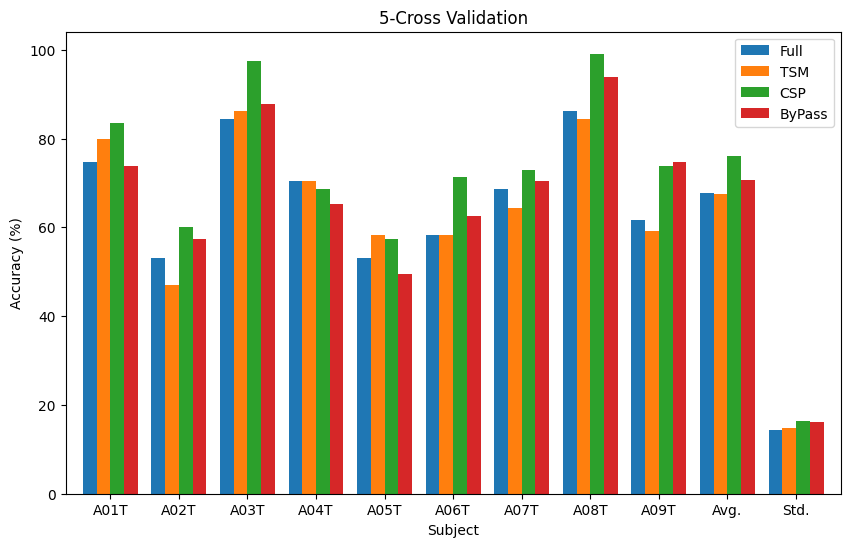

In [28]:
def robust_plot(robust_result):
    robust_result = robust_result.set_index('Subject')
    ax = robust_result.plot.bar(figsize=(10, 6), width=0.8, rot=0)
    plt.ylabel("Accuracy (%)")
    plt.title("5-Cross Validation")
    filename = saveResultPath +f"cv_score.png"
    filename = preprocess_filename(filename)
    plt.savefig(filename)
robust_plot(robust_result)


## Generalization

Confusion matrix saved to ./result_bci4_2a/ablation_accuracy.png
Confusion matrix saved to ./result_bci4_2a/ablation_precision.png
Confusion matrix saved to ./result_bci4_2a/ablation_recall.png
Confusion matrix saved to ./result_bci4_2a/ablation_f1.png
Confusion matrix saved to ./result_bci4_2a/ablation_kappa.png


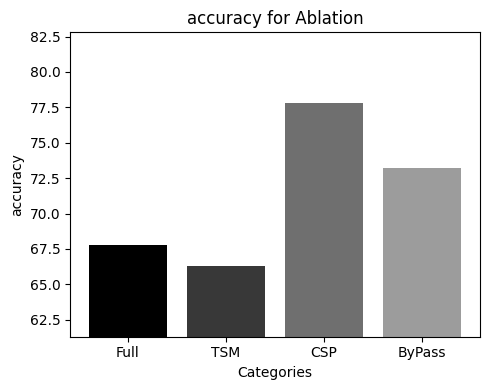

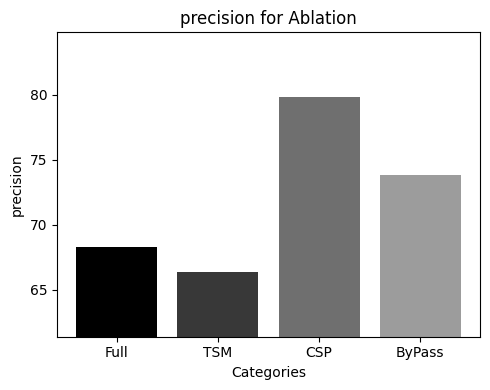

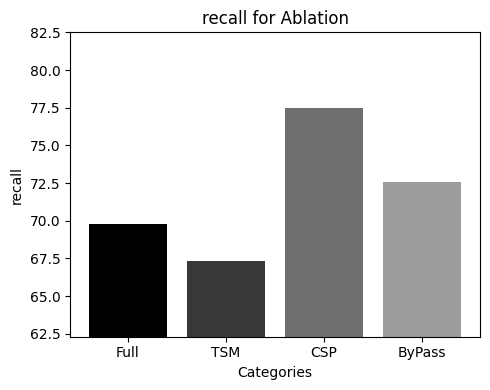

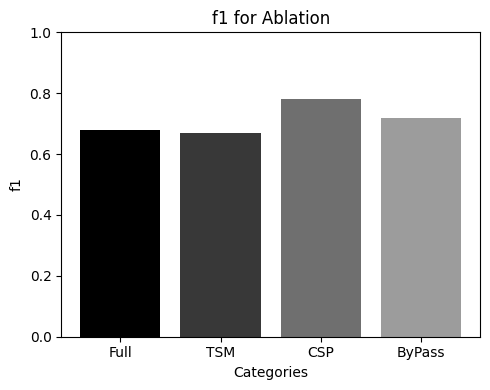

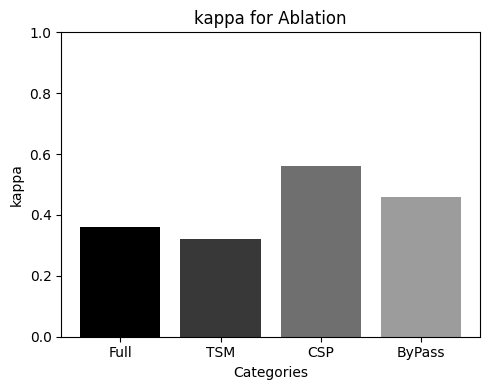

In [29]:
ablation_comparison(test_results)

## ROC

In [30]:
def plot_roc(results: dict, steps=100, title="ROC Curve"):
    """
    自定義 ROC 曲線繪製函數
    results[var][subject]['y_true']
    results[var][subject]['y_probs']
    """
    thresholds = np.linspace(1.1, -0.1, steps)

    variants, ablate_configs = ablation_config()
    cmap = plt.get_cmap('tab10')
    for var in variants:
        fig, ax = plt.subplots(figsize=(10, 8))
        last_sc = None
        for i, subject in enumerate(participants):
            roc_points = []
            y_probs = results[var][subject]['y_probs']
            y_true = results[var][subject]['y_true']
            for tau in thresholds:
                y_pred = (y_probs >= tau).astype(int)
                # 手動計算 TN, FP, FN, TP
                # 真實為 0 且 預測為 0
                tn = np.sum((y_true == 0) & (y_pred == 0))
                # 真實為 0 且 預測為 1 (誤報)
                fp = np.sum((y_true == 0) & (y_pred == 1))
                # 真實為 1 且 預測為 0 (漏報)
                fn = np.sum((y_true == 1) & (y_pred == 0))
                # 真實為 1 且 預測為 1
                tp = np.sum((y_true == 1) & (y_pred == 1))

                # 計算比例
                tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
                fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
                roc_points.append({'Threshold': tau, 'FPR': fpr, 'TPR': tpr})
            df_roc_sorted = pd.DataFrame(roc_points).sort_values(by='FPR')
            fpr = df_roc_sorted['FPR']
            tpr = df_roc_sorted['TPR']
            color = cmap(i % 10)
            ax.plot(df_roc_sorted['FPR'], df_roc_sorted['TPR'],
                     color=color, lw=2, label=f'{subject}', alpha=0.5, zorder=2)
            last_sc = plt.scatter(df_roc_sorted['FPR'], df_roc_sorted['TPR'],
                     c=df_roc_sorted['Threshold'], cmap='viridis',
                     s=25, alpha=0.9, edgecolor='none', zorder=3)
        plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        if last_sc:
            # 使用更細緻的 Colorbar 設定
            cbar = fig.colorbar(last_sc, ax=ax, shrink=0.8, pad=0.03)
            cbar.set_label('Threshold', rotation=270, labelpad=15)
        plt.xlim([0.0, 1.0]) # FPR 範圍 0~1
        plt.ylim([0.0, 1.05]) # TPR 範圍 0~1 (多給一點空間)
        plt.xlabel('False Positive Rate (1 - Specificity)')
        plt.ylabel('True Positive Rate (Recall/Sensitivity)')
        plt.title(f'ROC Curve {var}')
        plt.legend(loc="lower right") # 圖例放在右下角
        plt.grid(True, alpha=0.3) # 加入淡雅的網格
        plt.tight_layout()
        filename = saveResultPath +f"roc_{var}.png"
        filename = preprocess_filename(filename)
        fig.savefig(filename)


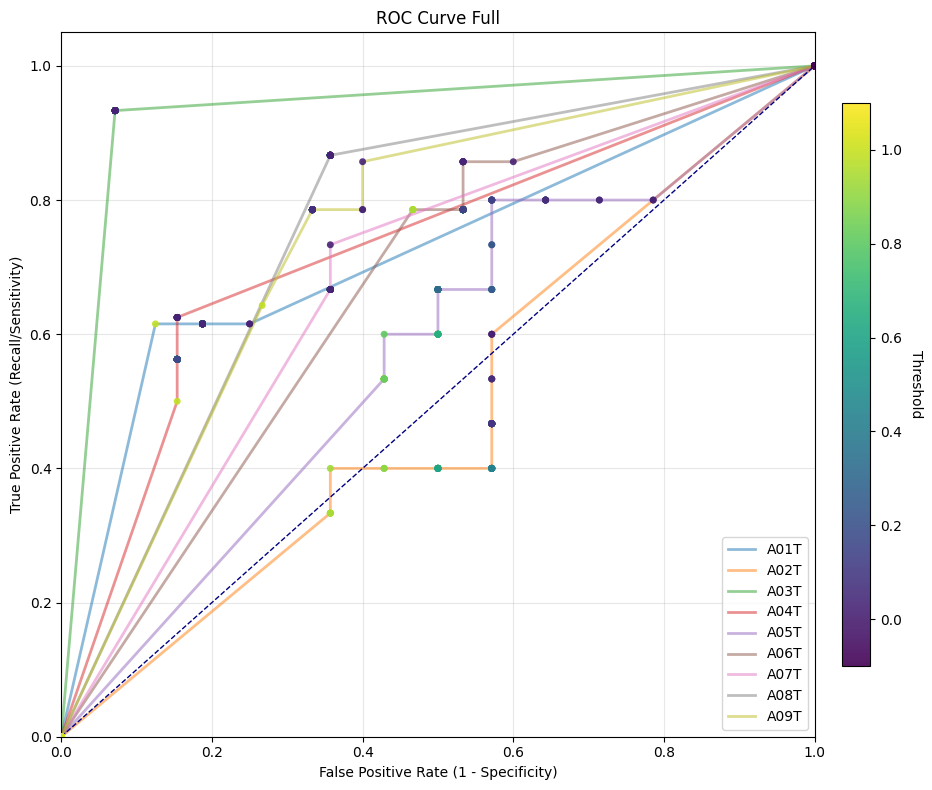

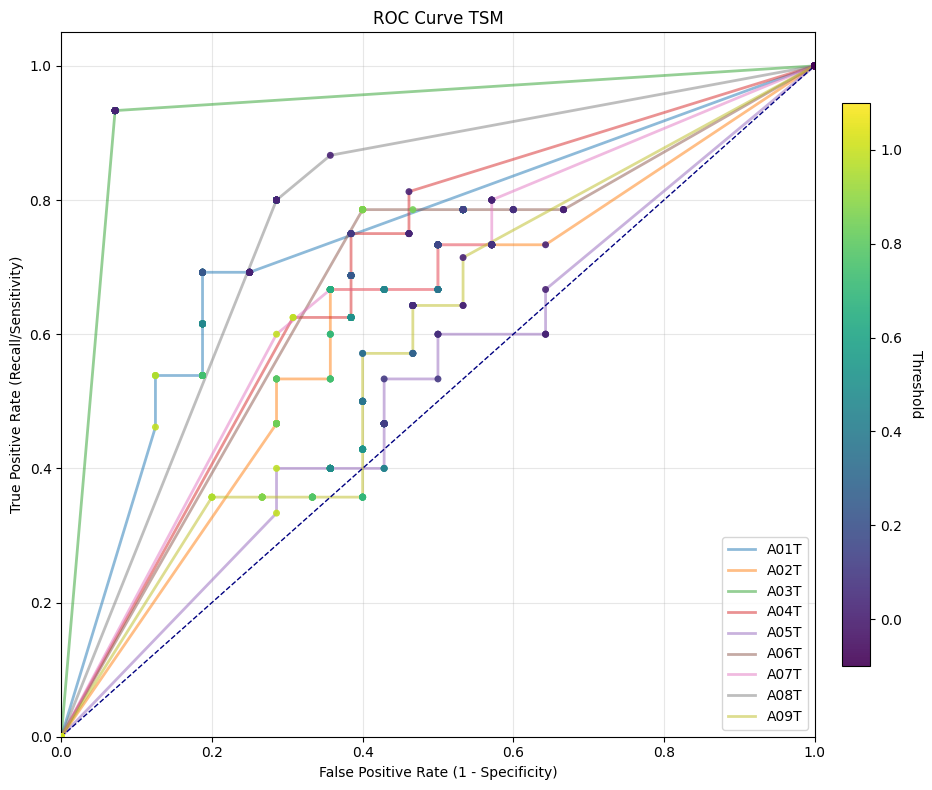

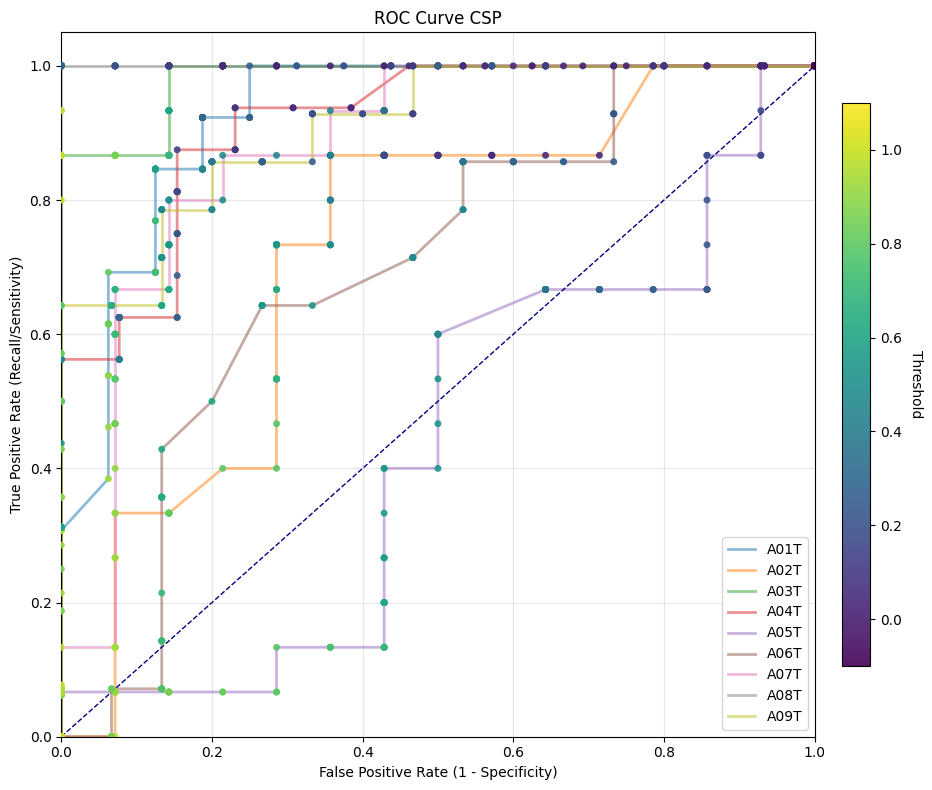

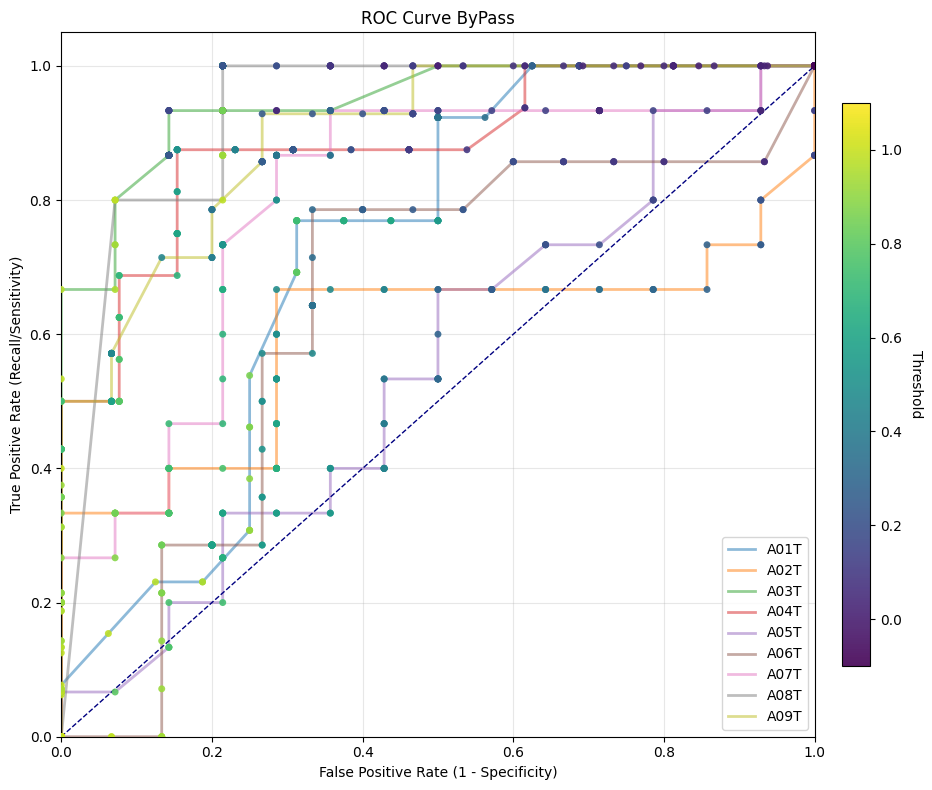

In [31]:
plot_roc(results)

# End

In [32]:
end_time = time.time()
duration = end_time - start_time
print(f"--- 處理完成 ---")
print(f"總共花費時間: {duration:.4f} 秒")

--- 處理完成 ---
總共花費時間: 63.2451 秒


# riemann k mean

In [33]:
# import numpy as np
# from scipy.linalg import logm, expm, inv, sqrtm
# from pyriemann.clustering import Kmeans as pyKmeans

# # --- 1. 手寫黎曼平均值 (更新中心點用) ---
# def riemannian_mean_single(covs, max_iter=20):
#     P = np.mean(covs, axis=0) # 初始值用歐氏平均
#     for _ in range(max_iter):
#         P_sqrt = sqrtm(P)
#         P_inv_sqrt = inv(P_sqrt)

#         # 切空間位移量
#         tangent_mean = np.zeros_like(P)
#         for C in covs:
#             tangent_mean += logm(P_inv_sqrt @ C @ P_inv_sqrt)
#         tangent_mean /= len(covs)

#         if np.linalg.norm(tangent_mean) < 1e-9:
#             break
#         P = P_sqrt @ expm(tangent_mean) @ P_sqrt
#     return P

# # --- 2. 手寫黎曼距離 (分配群組用) ---
# def riemannian_dist(E1, E2):
#     # 使用 np.linalg.eigvals 計算廣義特徵值更穩定
#     evals = np.linalg.eigvals(np.linalg.inv(E1) @ E2)
#     return np.sqrt(np.sum(np.log(np.real(evals))**2))

# # --- 3. 手寫 Riemannian K-means 類別 ---
# class ManualRiemannianKMeans:
#     def __init__(self, n_clusters=2, max_iter=10):
#         self.n_clusters = n_clusters
#         self.max_iter = max_iter
#         self.centroids = None

#     def fit(self, X):
#         # 隨機初始化中心點
#         idx = np.random.choice(len(X), self.n_clusters, replace=False)
#         self.centroids = [X[i] for i in idx]

#         for _ in range(self.max_iter):
#             # Step A: 分配群組 (Assign)
#             clusters = [[] for _ in range(self.n_clusters)]
#             for cov in X:
#                 dists = [riemannian_dist(cov, c) for c in self.centroids]
#                 clusters[np.argmin(dists)].append(cov)

#             # Step B: 更新中心 (Update)
#             new_centroids = []
#             for i in range(self.n_clusters):
#                 if len(clusters[i]) > 0:
#                     new_centroids.append(riemannian_mean_single(clusters[i]))
#                 else:
#                     new_centroids.append(self.centroids[i]) # 沒分到點則保持不變

#             self.centroids = new_centroids
#         return self

# # --- 4. 比較與驗證 ---
# if __name__ == "__main__":
#     # 模擬 10 筆 2x2 的協方差矩陣 (兩群數據)
#     n_trials = 100
#     n_channels = 8  # 假設是 8 通道 EEG
#     np.random.seed(42)

#     # 生成 100 個隨機的 SPD 矩陣 (模擬 EEG Trials)
#     # 我們讓它們圍繞在單位矩陣附近，帶有一點隨機擾動
#     X = []
#     for _ in range(n_trials):
#         # 生成隨機矩陣 A，其協方差 A*A^T 必為正定
#         A = np.eye(n_channels) + 0.2 * np.random.randn(n_channels, n_channels)
#         X.append(A @ A.T)
#     X = np.array(X)

#     # A. 手寫版
#     model_manual = ManualRiemannianKMeans(n_clusters=2).fit(X)

#     # B. Pyriemann 版
#     model_py = pyKmeans(n_clusters=2, metric='riemann').fit(X)

#     print("--- 中心點比較 (第一群) ---")
#     # print("Manual:\n", model_manual.centroids[0])
#     # 將 centroids[0] 改為 centroids()[0]
#     # print("Pyriemann:\n", model_py.centroids()[0])

#     # 計算兩者中心點的差異
#     # 修正處：將 model_py.centroids_[0] 改為 model_py.centroids()[0]
#     diff = riemannian_dist(model_manual.centroids[0], model_py.centroids()[0])
#     print(f"\n兩者中心點的黎曼距離差異: {diff:.2e}")

In [34]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.linalg import logm, inv, eigvals

# # --- 沿用你的黎曼距離函數 ---
# def riemannian_dist(E1, E2):
#     # 加上微小的 epsilon 確保數值穩定 (Regularization)
#     eps = 1e-9 * np.eye(E1.shape[0])
#     evals = np.linalg.eigvals(inv(E1 + eps) @ (E2 + eps))
#     return np.sqrt(np.sum(np.log(np.real(evals))**2))

# # --- 實驗設定 ---
# n_trials = 100
# n_channels = 8  # 假設是 8 通道 EEG
# np.random.seed(42)

# # 生成 100 個隨機的 SPD 矩陣 (模擬 EEG Trials)
# # 我們讓它們圍繞在單位矩陣附近，帶有一點隨機擾動
# X = []
# for _ in range(n_trials):
#     # 生成隨機矩陣 A，其協方差 A*A^T 必為正定
#     A = np.eye(n_channels) + 0.2 * np.random.randn(n_channels, n_channels)
#     X.append(A @ A.T)

# # --- 計算兩兩距離 (Pairwise Distances) ---
# dists = []
# for i in range(n_trials):
#     for j in range(i + 1, n_trials):
#         dists.append(riemannian_dist(X[i], X[j]))

# # --- 統計分析 ---
# dists = np.array(dists)
# print(f"平均黎曼距離: {np.mean(dists):.4f}")
# print(f"標準差: {np.std(dists):.4f}")
# print(f"最大距離: {np.max(dists):.4f}")
# print(f"最小距離: {np.min(dists):.4f}")

# # 繪製分布圖
# plt.figure(figsize=(10, 6))
# plt.hist(dists, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
# plt.axvline(np.mean(dists), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(dists):.2f}')
# plt.title(f"Distribution of Riemannian Distances (n={n_trials}, channels={n_channels})")
# plt.xlabel("Riemannian Distance")
# plt.ylabel("Frequency")
# plt.legend()
# plt.show()